# Lab 4: Enhancing the Bike Sharing System

Welcome to **Lab 4** of the Modeling & Simulation course! In this laboratory session, we will build upon the foundations laid in the previous labs to enhance our bike-sharing system simulation. This lab introduces the concept of **time slot-specific probabilities**, allowing you to model varying bike usage patterns throughout the day. Additionally, you will implement bike maintenance and downtime, develop a rebalancing mechanism, track customer satisfaction, and undertake a **graded assignment** to design and implement a comprehensive simulation project.

---

## Table of Contents

1. [Recap of Previous Labs](#recap)
2. [Introduction to Time Slot-Specific Probabilities](#time-slots)
   - [Understanding Time Slots](#understanding-time-slots)
3. [Implementing Time Slot-Specific Probabilities](#implementing-time-slots)
   - [Defining Time Slots](#defining-time-slots)
4. [Graded Assignment Overview](#assignment)

---

## <a name="recap"></a>1. Recap of Previous Labs

### Lab 1: Python Introduction
- Gained proficiency in Python programming.
- Learned fundamental programming concepts such as variables, data types, control structures, functions, and basic I/O operations.

### Lab 2: Basic Bike Sharing System Modeling
- Developed a simplified bike-sharing system using Python classes.
- Modeled entities such as stations, bikes, and trips.
- Implemented basic trip generation and analyzed system behavior over a short period.

### Lab 3: Introduction to SimPy
- Introduced SimPy, a discrete-event simulation library in Python.
- Reimplemented the bike-sharing system using SimPy constructs like environments, processes, and resources.
- Explored extensions including variable trip durations, rebalancing strategies, and customer satisfaction tracking.

---

## <a name="time-slots"></a>2. Introduction to Time Slot-Specific Probabilities

In real-world scenarios, bike usage varies throughout the day. To simulate this variability, we introduce **time slot-specific probabilities**. This enhancement allows the simulation to reflect different demand levels during various periods, such as morning rush hours and midday.

### <a name="understanding-time-slots"></a>Understanding Time Slots

- **Time Slots:** Defined periods within a day where bike trip probabilities differ.
- **Recurring Pattern:** Time slots repeat every simulated day, enabling multi-day simulations.
- **Example Time Slots:**
  - **Morning Start (0-120 minutes):** Initial hours with increasing demand.
  - **Midday (120-720 minutes):** Peak hours with stable high demand.

### <a name="mapping-time"></a>Mapping Simulation Time to Real-Time

To create realistic simulations, map simulation minutes to actual day times.

- **Simulation Start Time:** 6:00 AM
- **Morning Start:** 6:00 AM - 8:00 AM (0-120 minutes)
- **Midday:** 8:00 AM - 6:00 PM (120-720 minutes)
- **Simulation Duration:** 20 days (12 hours/day) → 14400 minutes

---

## <a name="implementing-time-slots"></a>3. Implementing Time Slot-Specific Probabilities

### <a name="defining-time-slots"></a>Defining Time Slots

Define time slots with specific trip probability matrices within a single day. Use the modulo operation to map the current simulation time to the appropriate time slot.

```python
# Define time slots for a single day
time_slots = [
    {
        'name': 'morning_start',
        'start': 0,       # 0 minutes into the day (6:00 AM)
        'end': 120,       # 2 hours
        'prob_matrix': {
            ('A', 'B'): 0.4,
            ('B', 'A'): 0.6,
            ('A', 'C'): 0.2,
            ('C', 'A'): 0.5,
            ('B', 'C'): 0.3,
            ('C', 'B'): 0.4,
            ('A', 'D'): 0.3,
            ('D', 'A'): 0.2,
        }
    },
    {
        'name': 'midday',
        'start': 120,      # 2 hours into the day (8:00 AM)
        'end': 720,        # 12 hours total (6:00 PM)
        'prob_matrix': {
            ('A', 'B'): 0.2,
            ('B', 'A'): 0.3,
            ('A', 'C'): 0.1,
            ('C', 'A'): 0.2,
            ('B', 'C'): 0.25,
            ('C', 'B'): 0.35,
            ('A', 'D'): 0.15,
            ('D', 'A'): 0.25,
        }
    }
    # Add more time slots if needed
]

# Define default probability matrix if no slot matches
default_prob_matrix = {
    ('A', 'B'): 0.05,
    ('B', 'A'): 0.05,
    ('A', 'C'): 0.05,
    ('C', 'A'): 0.05,
    ('B', 'C'): 0.05,
    ('C', 'B'): 0.05,
    ('A', 'D'): 0.05,
    ('D', 'A'): 0.05,
}


In [19]:
# Start from the code you've implemented in lab 3, add time-slot specific probabilities below


## <a name="assignment"></a>Graded Assignment Overview

Design and implement an enhanced bike-sharing system simulation using **SimPy**, incorporating advanced features to model a realistic and complex environment. Your simulation should build upon the concepts learned in previous labs and include the following components:

---

Your simulation must include the following elements:

### 1. Multiple Stations:

- **Minimum of Four stations** with varying capacities and initial bike counts.
- Each station should have a unique name, capacity, and initial number of bikes.

### 2. Time-Dependent Trip Probabilities:

- Implement trip probabilities that change based on different time slots (e.g., morning start, midday).
- Define at least **two distinct time slots** with different probability matrices.
- Ensure that time slots are **recurring daily** over the simulation period.

### 3. Bike Maintenance and Downtime:

- Model bike failures with a specified failure probability during trips.
- Implement a repair process that handles broken bikes, making them unavailable until repaired. The implementation details are up to your imagination.
- Track and report the number of bikes under maintenance.

### 4. Rebalancing Mechanism:

- Develop a rebalancing strategy to redistribute bikes between stations based on current demand and bike levels.
- Rebalancing should occur at regular intervals (e.g., every 20 minutes) and follow defined criteria.

### 5. Customer Satisfaction Tracking:

- Track the number of **unhappy customers** who cannot rent a bike due to unavailability.
- Track the number of **unhappy customers** who cannot return a bike due to full stations.

### 6. Data Collection and Visualization:

- Collect data on **bike levels** at each station over time.
- Collect data on **broken bikes** and maintenance activities.
- Collect data on **customer satisfaction** metrics.
- Generate plots to visualize:
  - **Bike levels** at each station over time.
  - **Number of bikes under maintenance**.
  - **Customer satisfaction metrics** (e.g., unhappy customers over time).

### 7. Simulation:

- Allow the simulation to run for a configurable duration (e.g., **20 days**).
- Parameters such as the number of stations, capacities, initial bikes, trip probabilities, maintenance rates, rebalancing intervals, and simulation duration should be easily adjustable.
- Simulate and observe the system with various parameters.

---

#### (Optional) Money Earning Mechanism:

- Introduce a system where the bike-sharing service earns **money based on bike rentals** (e.g., per hour rented).
- Track and report **total earnings** over the simulation period.

## What to Look For in Your Simulations

The primary objective of this lab is to enable you to create a realistic and dynamic simulation of a bike-sharing system that accounts for daily usage patterns, system maintenance, and operational strategies. Things to look for:

* Bike Availability: Assess how well the rebalancing mechanism maintains adequate bike levels across stations.
* Maintenance Impact: Evaluate the effect of bike failures on system performance and customer satisfaction.
* Customer Satisfaction: Analyze the number of unhappy customers and identify patterns or causes.

Write down a couple of observations from your simulations to accompany the presentation of your system.

## Grading

You will present your work in the upcoming laboratory, showing your system implementation and 1-3 simulations that you ran. The simulations should be accompanied by visual plots and you are encouraged to present any interesting observations about your system (e.g. with environment setup X the customer dissatisfaction drops significantly when increasing the rebalancing frequency to value y).

The project grade will be determined by the grade of completion of your system (how much of the project task has been implemented), as well as your understanding of it. The latter will be assessed through some basic questions about your model/system/simulations.

*Note: Where not strongly specified, you are free to design a subsystem/idea however you find best fit, e.g. points 2, 3 and 4 can have many different subsystem designs. There is no one correct way to do it.

In [20]:
!pip install simpy

Importurile necesare:

In [21]:
#Aici fac import la cam tot ce imi trebuie
import simpy
import random
import matplotlib.pyplot as plt

#random.seed(42) # Set a seed for reproducibility

In [22]:
#Incepem cu definirea claselor si a obiectelor

# Defining the Station Class
class Station:
    def __init__(self, env, name, capacity, init_bikes):
        self.env = env
        self.name = name
        self.capacity = capacity
        self.bikes = simpy.Container(env, init=init_bikes, capacity=capacity)

# Start the trip generation process
env = simpy.Environment()

#initilaizam statiile
complex_station = Station(env, "complex",     capacity=22, init_bikes=13)
upt_station = Station(    env, "UPT",         capacity=21, init_bikes=8)
center_station = Station( env, "Centru",      capacity=20, init_bikes=10)
iulius_station = Station( env, "Iulius Town", capacity=24, init_bikes=11)

#punem statiile intro lista pentru a le accesa in simulare
stations = [complex_station , upt_station, center_station, iulius_station]

# Reinitialize the bike_levels dictionary
bike_levels = {station.name: [] for station in stations}


In [23]:
#Aici o sa punem Time-Slot Probablity implementation
"""
24 h * 60 min = 1440 minutes -> a day
6AM ==> 6 * 60 = 360 minutes
9AM ==> 9 * 60 = 540 minutes
3PM ==> 15 * 60 = 900 minutes
6PM ==> 18 * 60 = 1080 minutes
24 ==> 24 * 60 = 1440 minutes
Intervale:
00:00 -> 06:00  //practic 0 probabilitati
06:00 -> 09:00  // HIGH           , oamenii se duc spre univer/lucru
09:00 -> 15:00  // MEDIU          , numarul de oameni liberi in asa ore e mic dar sunt
15:00 -> 18:00  // HIGH           , oamenii vin acasă
18:00 -> 24:00  // MEDIU spre LOW , majoritate sunt acasa si nu prea se primbla oamenii seara cu bicicletele
"""
# Define time slots for a single day
time_slots = [
    {
        'name': 'Night',
        'start': 0,       # 0 minutes into the day (00:00 AM)
        'end': 360,       # 6 hours
        'prob_matrix': {
            (complex_station, upt_station):    0.004,  # very low
            (complex_station, center_station): 0.006,  # very low
            (complex_station, iulius_station): 0.004,  # very low

            (upt_station, complex_station):    0.004,  # very low
            (upt_station, center_station):     0.006,  # very low
            (upt_station, iulius_station):     0.004,  # very low

            (center_station, complex_station): 0.006,  # very low
            (center_station, upt_station):     0.006,  # very low
            (center_station, iulius_station):  0.010,  # slightly more leisure

            (iulius_station, complex_station): 0.004,  # very low
            (iulius_station, upt_station):     0.004,  # very low
            (iulius_station, center_station):  0.008,  # very low
        }
    },
    {
        'name': 'Morning_Start',
        'start': 360,       # 360 minutes into the day (6:00 AM)
        'end': 540,         # 3 hours (9:00 AM)
        'prob_matrix': {
            (complex_station, upt_station):    0.18,   # was 0.6
            (complex_station, center_station): 0.14,   # was 0.5
            (complex_station, iulius_station): 0.10,   # was 0.4

            (upt_station, complex_station):    0.08,   # was 0.3
            (upt_station, center_station):     0.03,   # was 0.1
            (upt_station, iulius_station):     0.06,   # was 0.2

            (center_station, complex_station): 0.03,   # was 0.1
            (center_station, upt_station):     0.15,   # was 0.5
            (center_station, iulius_station):  0.09,   # was 0.3

            (iulius_station, complex_station): 0.03,   # was 0.1
            (iulius_station, upt_station):     0.18,   # was 0.6
            (iulius_station, center_station):  0.12,   # was 0.4
        }
    },
    {
        'name': 'Mid_Day',
        'start': 540,       # 540 minutes into the day (9:00 AM)
        'end': 900,         # 6 hours (3:00 PM)
        'prob_matrix': {
            # Medium, flatter flows; keep Center/Iulius slightly busier [file:1]
            (complex_station, upt_station):    0.08,   # was 0.4
            (complex_station, center_station): 0.10,   # was 0.5
            (complex_station, iulius_station): 0.10,   # was 0.5

            (upt_station, complex_station):    0.05,   # was 0.2
            (upt_station, center_station):     0.06,   # was 0.2
            (upt_station, iulius_station):     0.06,   # was 0.2

            (center_station, complex_station): 0.06,   # was 0.2
            (center_station, upt_station):     0.06,   # was 0.2
            (center_station, iulius_station):  0.08,   # was 0.3

            (iulius_station, complex_station): 0.06,   # was 0.2
            (iulius_station, upt_station):     0.06,   # was 0.2
            (iulius_station, center_station):  0.08,   # was 0.3
        }
    },
    {
        'name': 'Afternoon',
        'start': 900,       # 900 minutes into the day (3:00 PM)
        'end': 1080,        # 3 hours (6:00 PM)
        'prob_matrix': {
            (complex_station, upt_station):    0.04,   # was 0.1
            (complex_station, center_station): 0.08,   # was 0.3
            (complex_station, iulius_station): 0.06,   # was 0.2

            (upt_station, complex_station):    0.18,   # was 0.6
            (upt_station, center_station):     0.12,   # was 0.4
            (upt_station, iulius_station):     0.14,   # was 0.5

            (center_station, complex_station): 0.12,   # was 0.5
            (center_station, upt_station):     0.06,   # was 0.2
            (center_station, iulius_station):  0.12,   # was 0.4

            (iulius_station, complex_station): 0.12,   # was 0.5
            (iulius_station, upt_station):     0.08,   # was 0.3
            (iulius_station, center_station):  0.12,   # was 0.4
        }
    },
    {
        'name': 'End_Day',
        'start': 1080,       # 1080 minutes into the day (6:00 PM)
        'end': 1440,         # 6 hours (24:00)
        'prob_matrix': {
            (complex_station, upt_station):    0.02,   # was 0.05
            (complex_station, center_station): 0.04,   # was 0.10
            (complex_station, iulius_station): 0.06,   # was 0.15

            (upt_station, complex_station):    0.02,   # was 0.05
            (upt_station, center_station):     0.04,   # was 0.10
            (upt_station, iulius_station):     0.06,   # was 0.15

            (center_station, complex_station): 0.04,   # was 0.10
            (center_station, upt_station):     0.04,   # was 0.10
            (center_station, iulius_station):  0.08,   # was 0.20

            (iulius_station, complex_station): 0.04,   # was 0.10
            (iulius_station, upt_station):     0.04,   # was 0.10
            (iulius_station, center_station):  0.06,   # was 0.15
        }

    }
    # Add more time slots if needed
]

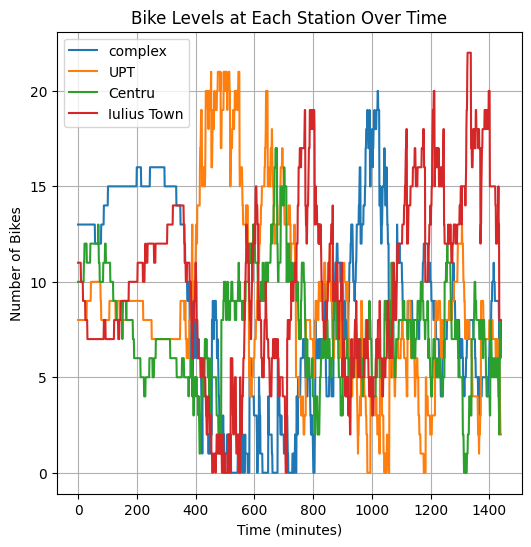

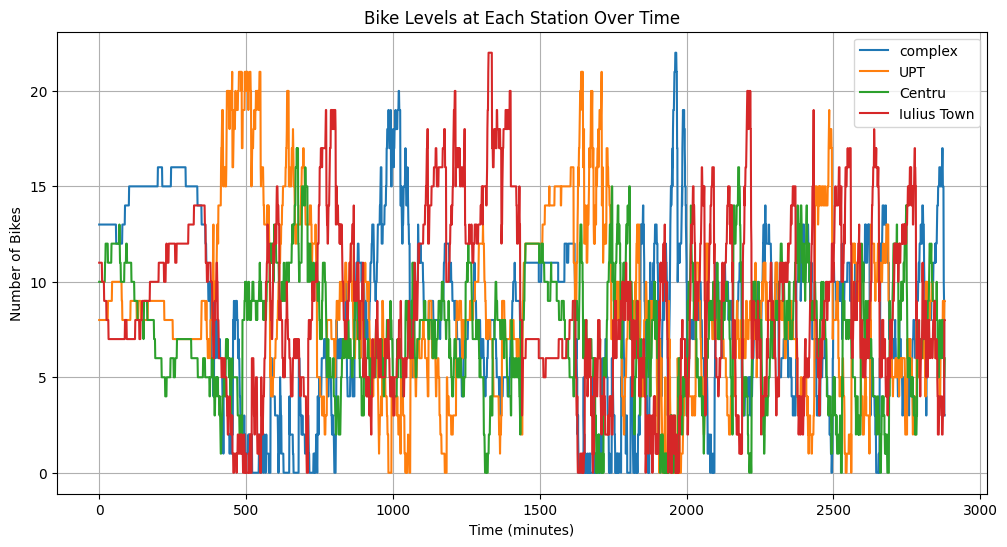

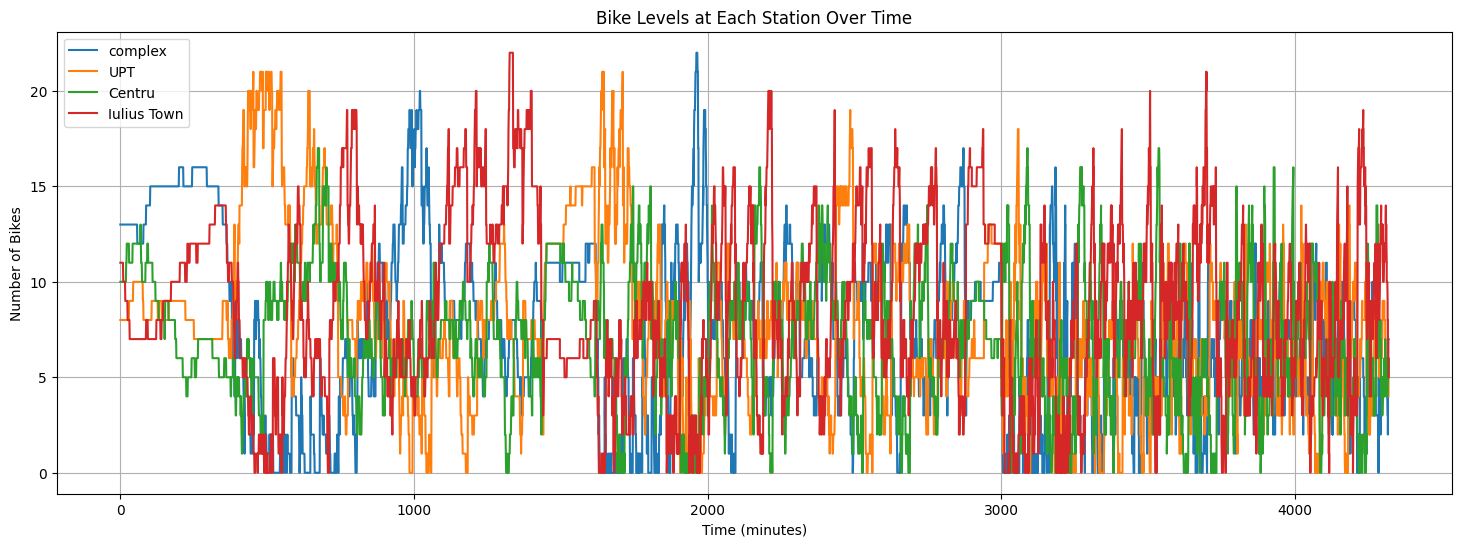

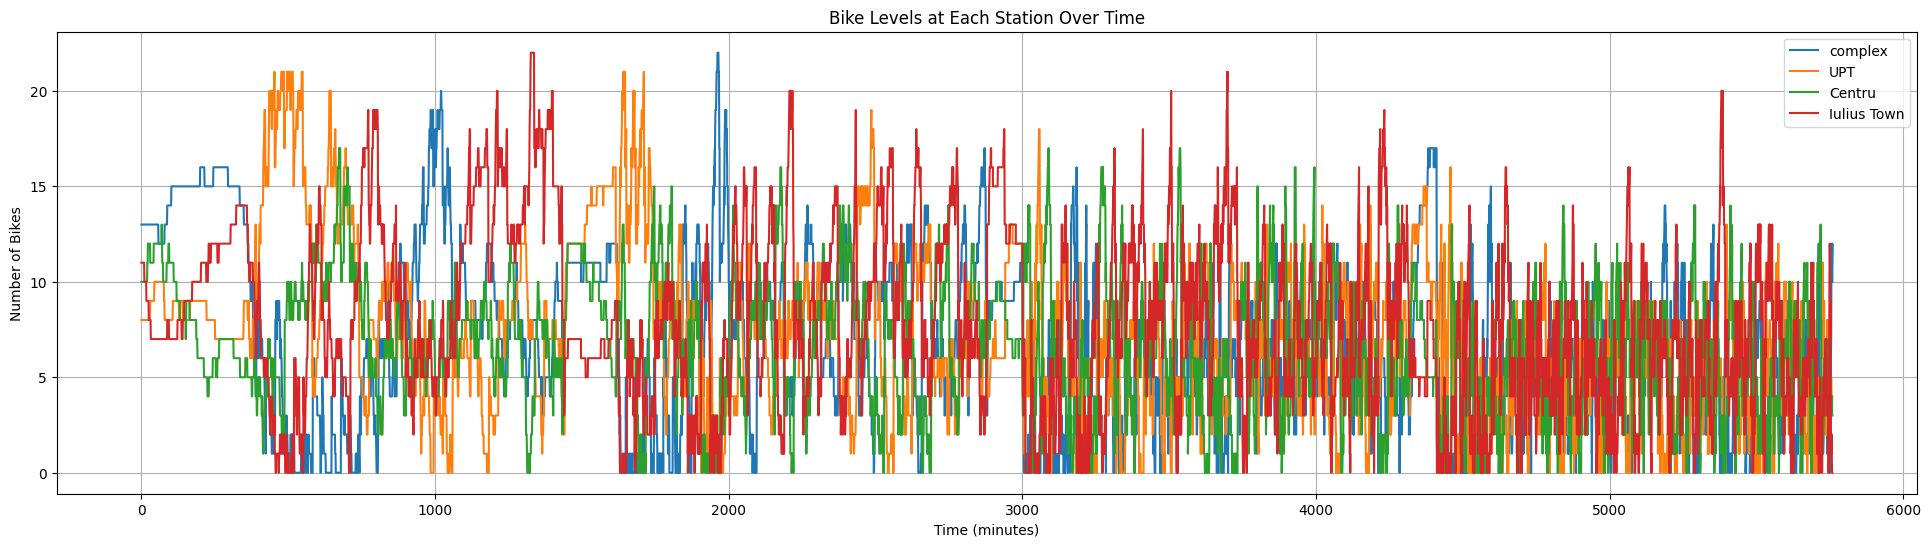

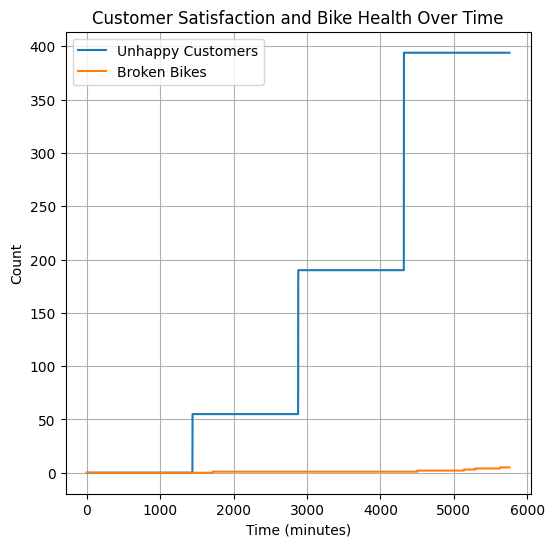

Total Unhappy customers = 690
Average Unhappy customers = 74.0
Total broken bikes = 5
Average broken bikes = 1.25
complex: 10
UPT: 4
Centru: 3
Iulius Town: 0


In [24]:
#actual logic of the program with all the functions and simulation process

unhappy_customers = [0]
time_counter = [0]
current_broken_bikes = [0]
total_broken_bikes = [0]

broken_bikes_over_time = []
unhappy_customers_over_time = []
time_points = []

#asta e codul unde vom introduce unhappy custormers count
def bike_trip(env, from_station, to_station, trip_duration):
    if from_station.bikes.level > 0:
        yield from_station.bikes.get(1)
        #print(f"Time {env.now}: Bike taken from {from_station.name}")
    else:
        #print(f"Time {env.now}: No bikes available at {from_station.name}")
        unhappy_customers[0] += 1   # highlight: count unhappy customer
        return

    yield env.timeout(trip_duration)

    broken = breaking_sys(0.001)                                                #aici determin daca sa stricat bicicleta sau nu

    if to_station.bikes.level < to_station.capacity:
        yield to_station.bikes.put(1)
        #print(f"Time {env.now}: Bike returned to {to_station.name}")
        if broken:
          yield env.process(repair_bike(broken, to_station))

    else:
        #print(f"Time {env.now}: No docks available at {to_station.name}, returning bike to {from_station.name}")
        unhappy_customers[0] += 1  # highlight: count unhappy customer
        yield env.timeout(trip_duration)
        if from_station.bikes.level < from_station.capacity: #inceaca sa o puna inapoi
            yield from_station.bikes.put(1)
            #print(f"Time {env.now}: Bike returned to {from_station.name}")
            if broken:
              yield env.process(repair_bike(broken, from_station))
        else:
            yield env.timeout(random.randint(1, 15)) #daca nu o poate pune, asteapta pana in 15 minute si o pune la loc
            yield from_station.bikes.put(1)
            if broken:
              yield env.process(repair_bike(broken, from_station))
    return

def monitor_stations(env, stations, bike_levels, broken_bikes_over_time, unhappy_customers_over_time, time_points):
    while True:
        for station in stations:
            bike_levels[station.name].append((env.now, station.bikes.level))
            broken_bikes_over_time.append(total_broken_bikes[0])
            unhappy_customers_over_time.append(total_unhappy_customers)
            time_points.append(env.now)

        time_counter[0] += 1 #incrementam cu cate un minut
        #am ales sa o pun aici din cauza ca e mai usor de vazut decat o functie mai complexa ca generate trips si se potriveste tematicii fuctiei

        yield env.timeout(1)

def generate_trips(env):
    while True:
        for slot in time_slots:  #aici cautam in ce probability suntem (Intervalul de ore)
          if slot['start'] <= time_counter[0] < slot['end']:
            curent_prob_matrix = slot['prob_matrix']
            break
        for (from_station, to_station), prob in curent_prob_matrix.items():
            if random.uniform(0, 1) < prob:
                trip_duration = random.randint(5, 15)                                                     #aici e intervalul de timp
                env.process(bike_trip(env, from_station, to_station, trip_duration))  # highlight: pass list
        yield env.timeout(1)

def breaking_sys(probability):
  chance = random.uniform(0,1)
  if (chance > probability):    #ex prob = 0.001
    return False
  else:
    return True

def repair_bike(e_stricat, station):  #va lua the bike care o ajuns la statie si o va pune intru-un cooldown pentru a o repara
  if (e_stricat):
    yield station.bikes.get(1)
    current_broken_bikes[0] += 1
    total_broken_bikes[0] += 1
    yield env.timeout(60)              #se va repara dupa o ora
    yield station.bikes.put(1)
    current_broken_bikes[0] -= 1
  else:
    return

def rebalancing(env, stations):

    max_limit = 17 #aproape full
    min_limit = 5 #40%
    num_to_move = 5

    while True:
      max_bikes = stations[0].bikes.level
      min_bikes = stations[0].bikes.level

      max_bikes_station = stations[0]
      min_bikes_station = stations[0]

      for station in stations:
          if station.bikes.level > max_bikes:
            max_bikes = station.bikes.level
            max_bikes_station = station

          elif station.bikes.level < min_bikes:
            min_bikes = station.bikes.level
            min_bikes_station = station

      if (max_bikes_station.bikes.level > max_limit and min_bikes_station.bikes.level + num_to_move <= min_bikes_station.capacity) or min_bikes_station.bikes.level < min_limit : #verific sa avem statie de la care trebuie luat si ca avem loc sa punem in alta
            #print(f"Time {env.now}: Rebalancing - Moving {num_to_move} bikes from {max_bikes_station.name} to {min_bikes_station.name}")
            yield max_bikes_station.bikes.get(num_to_move)
            yield env.timeout(2) #asteptam 2 minute ca sa se mute
            yield min_bikes_station.bikes.put(num_to_move)
            '''
            print(f"Time {env.now}: Max bikes spec at {max_bikes_station.name} = {max_bikes_station.bikes.level}")
            print(f"Time {env.now}: Min bikes spec at {min_bikes_station.name} = {min_bikes_station.bikes.level}")
            print(f"Time {env.now}: Max bikes at {max_bikes_station.name} = {max_bikes}")
            print(f"Time {env.now}: Min bikes at {min_bikes_station.name} = {min_bikes}")
            '''





      yield env.timeout(30)

#Aparent trebuie sa reinitializez doate acestea ca sa pot rula back to back. Altfel se pastreaza simularea si trebuie sa dau rese la tot
# Run the simulationplt.figure(figsize=(12, 6)) # Set the figure size
def run_sim(run_time):

  #actual run
  env.process(generate_trips(env))  # highlight: pass list
  env.process(monitor_stations(env, stations, bike_levels, broken_bikes_over_time, unhappy_customers_over_time, time_points))
  env.process(rebalancing(env, stations))


  env.run(until=run_time)  # Run the simulation for 1440 minutes (24 hours)


n_days = 4
average_broken_bikes = 0
total_unhappy_customers = 0
average_unhappy_customers = 0
total_broken_bikes[0] = 0

for i in range(n_days):
  time_counter[0] = 0
  current_broken_bikes[0] = 0
  unhappy_customers[0] = 0

  run_time = (i + 1) * 1440
  run_sim(run_time)

  total_unhappy_customers += unhappy_customers[0]


  #afisam grafurile pentru fiecare zilele
  custom = (i + 1) * 6                                      #to make it bigger
  plt.figure(figsize=(custom, 6)) # Set the figure size
  for station_name, levels in bike_levels.items():
    times, counts = zip(*levels)
    plt.plot(times, counts, label=station_name)

  plt.xlabel('Time (minutes)')
  plt.ylabel('Number of Bikes')
  plt.title('Bike Levels at Each Station Over Time')
  plt.legend()
  plt.grid(True)
  plt.show()

  #restul grafurilor
plt.figure(figsize=(6, 6))
plt.plot(time_points, unhappy_customers_over_time, label="Unhappy Customers")
plt.plot(time_points, broken_bikes_over_time, label="Broken Bikes")
plt.xlabel("Time (minutes)")
plt.ylabel("Count")
plt.title("Customer Satisfaction and Bike Health Over Time")
plt.legend()
plt.grid(True)
plt.show()

#astea le aratam la final ca sunt average

average_broken_bikes = total_broken_bikes[0] / n_days
average_unhappy_customers = unhappy_customers[0] / n_days


print(f"Total Unhappy customers = {total_unhappy_customers}")
print(f"Average Unhappy customers = {average_unhappy_customers}")
print(f"Total broken bikes = {total_broken_bikes[0]}")
print(f"Average broken bikes = {average_broken_bikes}")

#DO I LOSE BIKES OVER TIME ?
for station in stations:
    print(f"{station.name}: {station.bikes.level}")
#NO, AM TESTAT SI ELE SE AFLA PE DRUMURI
